In [3]:
# !pip install yahoofinancials
# !pip install yfinance

In [4]:
# https://towardsdatascience.com/a-comprehensive-guide-to-downloading-stock-prices-in-python-2cd93ff821d4
# https://pypi.org/project/yfinance/
import sys

!{sys.executable} --version
# !{sys.executable} -m pip install yfinance
# !{sys.executable} -m pip install yahoofinancials

import pandas as pd
import yfinance as yf
from yahoofinancials import YahooFinancials
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

Python 3.11.5


# download Tesla price history

In [5]:
tsla_df = yf.download('TSLA', 
                      start='2019-01-01', 
                      end='2026-01-22',
                      progress=False, 
                      auto_adjust=True)
display(tsla_df.head())
display(tsla_df.tail())

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2019-01-02,20.674667,21.008667,19.920000,20.406668,174879000
2019-01-03,20.024000,20.626667,19.825333,20.466667,104478000
2019-01-04,21.179333,21.200001,20.181999,20.400000,110911500
2019-01-07,22.330667,22.449333,21.183332,21.448000,113268000
2019-01-08,22.356667,22.934000,21.801332,22.797333,105127500


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-01-14,439.200012,443.910004,434.220001,442.809998,57259500
2026-01-15,438.570007,445.359985,437.649994,441.130005,49465800
2026-01-16,437.500000,447.250000,435.260010,439.500000,60220600
2026-01-20,419.250000,430.730011,417.440002,429.359985,63187300
2026-01-21,431.440002,438.200012,419.619995,421.660004,68124000


In [6]:
import pickle
pickle.dump(tsla_df, open("tesla_data.pkl",'wb'))

In [7]:
t_data = pickle.load(open("tesla_data.pkl",'rb'))
t_data[:4]

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2019-01-02,20.674667,21.008667,19.920000,20.406668,174879000
2019-01-03,20.024000,20.626667,19.825333,20.466667,104478000
2019-01-04,21.179333,21.200001,20.181999,20.400000,110911500
2019-01-07,22.330667,22.449333,21.183332,21.448000,113268000


# plot Tesla price history

<Axes: title={'center': "TSLA's stock price"}, xlabel='Date'>

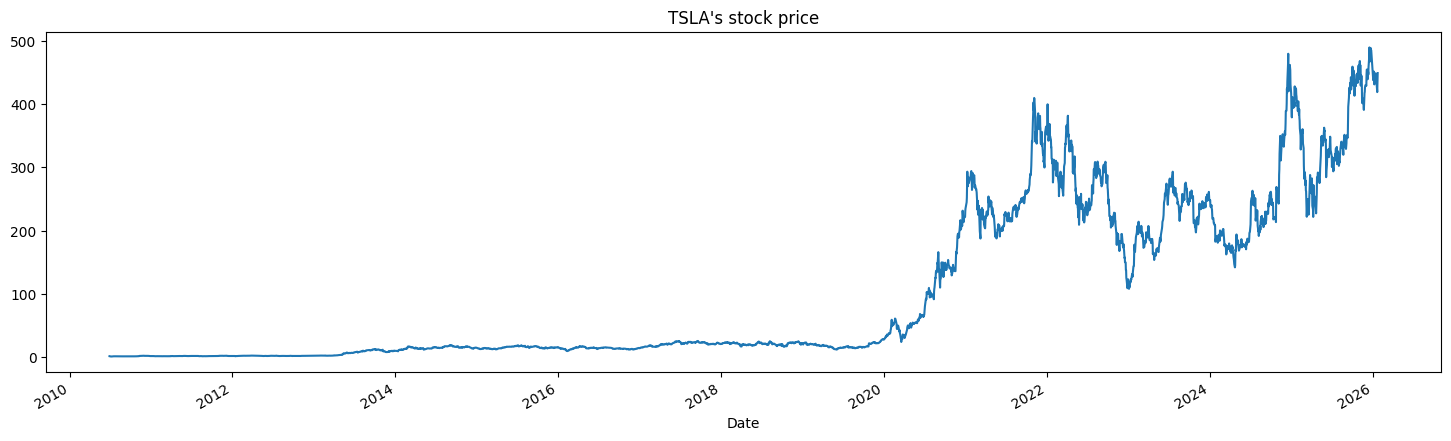

In [8]:
ticker = yf.Ticker('TSLA')
tsla_df2 = ticker.history(period="max")
plt.figure(figsize=(18,5))
tsla_df2['Close'].plot(title="TSLA's stock price")

# comparison of closing prices and adjusted closing price

In [9]:
start_date, tickers = '2010-01-01', ['F','XOM']
prices_df = yf.download(tickers, start=start_date, progress=False, auto_adjust=False)
display(prices_df.head())
prices_df = yf.download(tickers, start=start_date, progress=True, auto_adjust=True)
display(prices_df.head())
display(prices_df.tail())

Price      Adj Close             Close              High               Low  \
Ticker             F        XOM      F        XOM      F        XOM      F   
Date                                                                         
2010-01-04  5.287392  37.881794  10.28  69.150002  10.28  69.260002  10.05   
2010-01-05  5.637144  38.029709  10.96  69.419998  11.24  69.449997  10.40   
2010-01-06  5.848022  38.358410  11.37  70.019997  11.46  70.599998  11.13   
2010-01-07  5.997180  38.237881  11.66  69.800003  11.69  70.059998  11.32   
2010-01-08  6.012611  38.084496  11.69  69.519997  11.74  69.750000  11.46   

Price                   Open                Volume            
Ticker            XOM      F        XOM          F       XOM  
Date                                                          
2010-01-04  68.190002  10.17  68.720001   60855800  27809100  
2010-01-05  68.800003  10.45  69.190002  215620200  30174700  
2010-01-06  69.339996  11.21  69.449997  200070600  35044700  
2010-01-07  69.419998  11.46  69.900002  130201700  27192100  
2010-01-08  69.220001  11.67  69.690002  130463000  24891800

[*********************100%***********************]  2 of 2 completed


Price          Close                 High                  Low             \
Ticker             F        XOM         F        XOM         F        XOM   
Date                                                                        
2010-01-04  5.287393  37.881794  5.287393  37.942055  5.169096  37.355887   
2010-01-05  5.637143  38.029709  5.781158  38.046143  5.349114  37.690063   
2010-01-06  5.848023  38.358410  5.894314  38.676147  5.724582  37.985892   
2010-01-07  5.997180  38.237881  6.012610  38.380311  5.822305  38.029706   
2010-01-08  6.012611  38.084496  6.038328  38.210496  5.894313  37.920152   

Price           Open                Volume            
Ticker             F        XOM          F       XOM  
Date                                                  
2010-01-04  5.230816  37.646231   60855800  27809100  
2010-01-05  5.374831  37.903712  215620200  30174700  
2010-01-06  5.765729  38.046152  200070600  35044700  
2010-01-07  5.894312  38.292662  130201700  27192100  
2010-01-08  6.002324  38.177628  130463000  24891800

Price       Close               High                Low               Open  \
Ticker          F         XOM      F         XOM      F         XOM      F   
Date                                                                         
2026-01-15  13.81  129.130005  14.13  130.199997  13.79  128.300003  13.92   
2026-01-16  13.60  129.889999  13.80  130.160004  13.59  128.869995  13.76   
2026-01-20  13.28  130.460007  13.61  131.940002  13.23  130.070007  13.47   
2026-01-21  13.77  133.610001  13.77  133.729996  13.41  131.910004  13.41   
2026-01-22  13.71  133.639999  13.84  134.179993  13.70  131.850006  13.78   

Price                     Volume            
Ticker             XOM         F       XOM  
Date                                        
2026-01-15  129.130005  44241500  17400000  
2026-01-16  128.910004  60750800  16592400  
2026-01-20  131.509995  67018100  16477300  
2026-01-21  131.910004  58160100  18879900  
2026-01-22  133.050003  34173452  16547183

# compare arithmetic versus geometric returns

In [10]:
from math import log
display(prices_df[:3])

f"Jan 6, 2020 geometric return = {log(8.005848 / 7.717158):0.6f}, arithmetic return = {(8.005848 - 7.717158) /7.717158:0.6f}"

Price          Close                 High                  Low             \
Ticker             F        XOM         F        XOM         F        XOM   
Date                                                                        
2010-01-04  5.287393  37.881794  5.287393  37.942055  5.169096  37.355887   
2010-01-05  5.637143  38.029709  5.781158  38.046143  5.349114  37.690063   
2010-01-06  5.848023  38.358410  5.894314  38.676147  5.724582  37.985892   

Price           Open                Volume            
Ticker             F        XOM          F       XOM  
Date                                                  
2010-01-04  5.230816  37.646231   60855800  27809100  
2010-01-05  5.374831  37.903712  215620200  30174700  
2010-01-06  5.765729  38.046152  200070600  35044700

'Jan 6, 2020 geometric return = 0.036726, arithmetic return = 0.037409'

# calculate daily returns

In [11]:
import numpy as np
np.log(100)-np.log(50)

0.6931471805599458

In [12]:
from math import log

prices_f = prices_df[[('Close','F')]].squeeze()   # convert from dataframe to series
returns_f = prices_f.apply(log).diff()              # compute first order differences in the log prices = daily return
returns_f

Date
2010-01-04         NaN
2010-01-05    0.064052
2010-01-06    0.036726
2010-01-07    0.025186
2010-01-08    0.002570
                ...   
2026-01-15   -0.002170
2026-01-16   -0.015323
2026-01-20   -0.023811
2026-01-21    0.036233
2026-01-22   -0.004367
Name: (Close, F), Length: 4038, dtype: float64

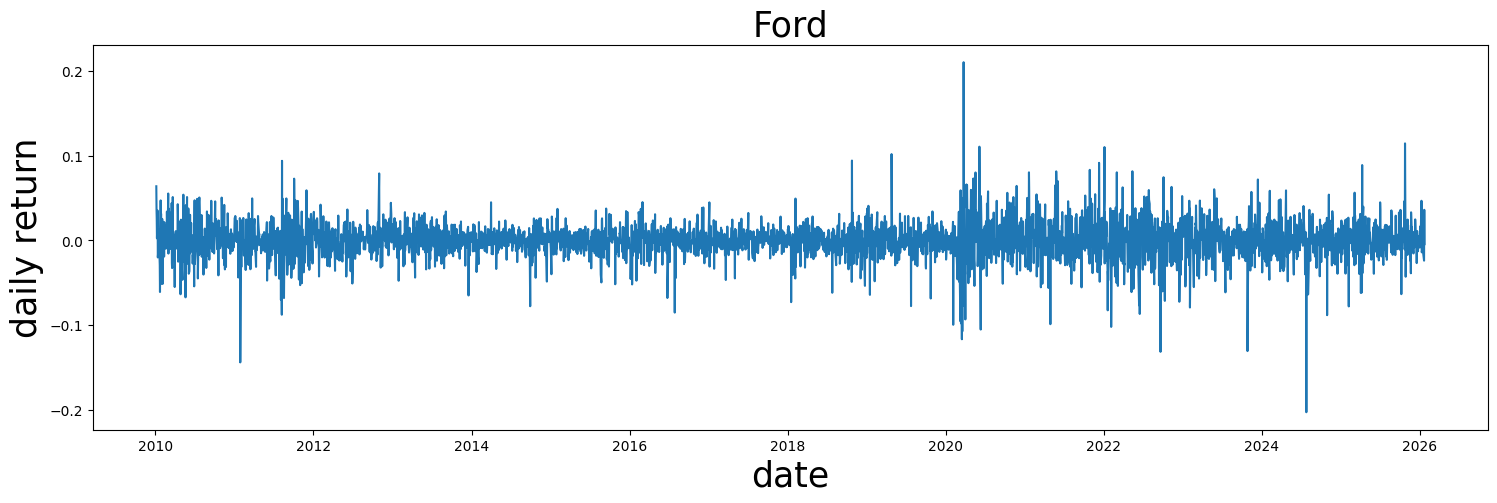

In [13]:
plt.figure(figsize=(18,5))
plt.plot(returns_f)
plt.title('Ford', fontsize=25)
plt.xlabel('date', fontsize=25)
plt.ylabel('daily return', fontsize=25)
plt.show()

# plot distribution of returns

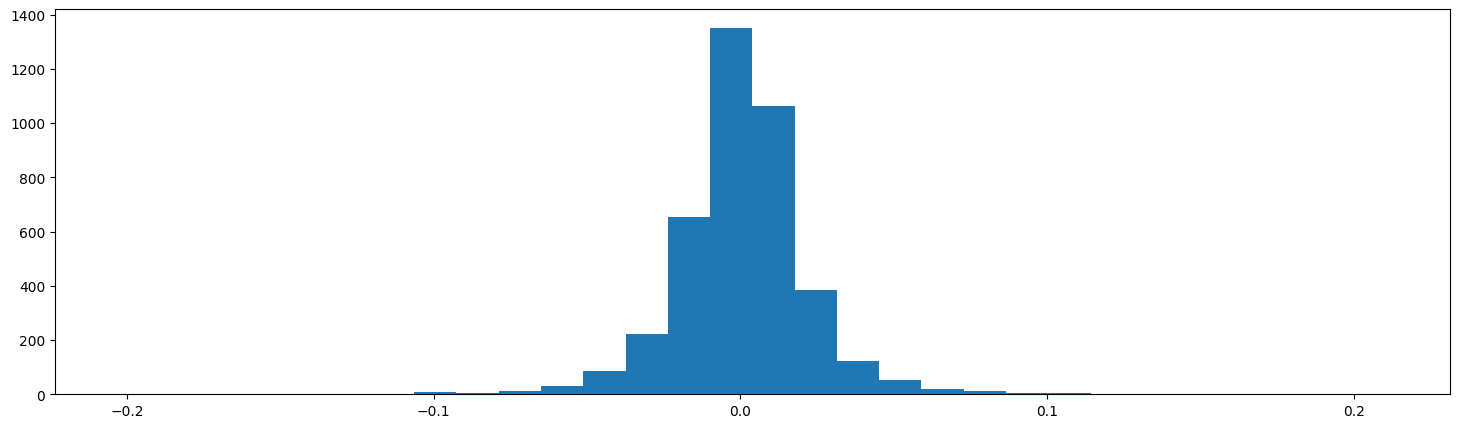

In [14]:
plt.figure(figsize=(18,5))
plt.hist(returns_f[1:],30)
plt.show()

In [15]:
import numpy as np
f"mean return = {np.mean(returns_f):0.6f} , return standard deviation = {np.std(returns_f):0.6f}"

'mean return = 0.000236 , return standard deviation = 0.021525'

# Exxon returns

In [16]:
prices_xom = prices_df[[('Close','XOM')]].squeeze()   # convert from dataframe to series
returns_xom = prices_xom.apply(log).diff()              # compute first order differences in the log prices = daily return
returns_xom

Date
2010-01-04         NaN
2010-01-05    0.003897
2010-01-06    0.008606
2010-01-07   -0.003147
2010-01-08   -0.004019
                ...   
2026-01-15   -0.008252
2026-01-16    0.005868
2026-01-20    0.004379
2026-01-21    0.023858
2026-01-22    0.000224
Name: (Close, XOM), Length: 4038, dtype: float64

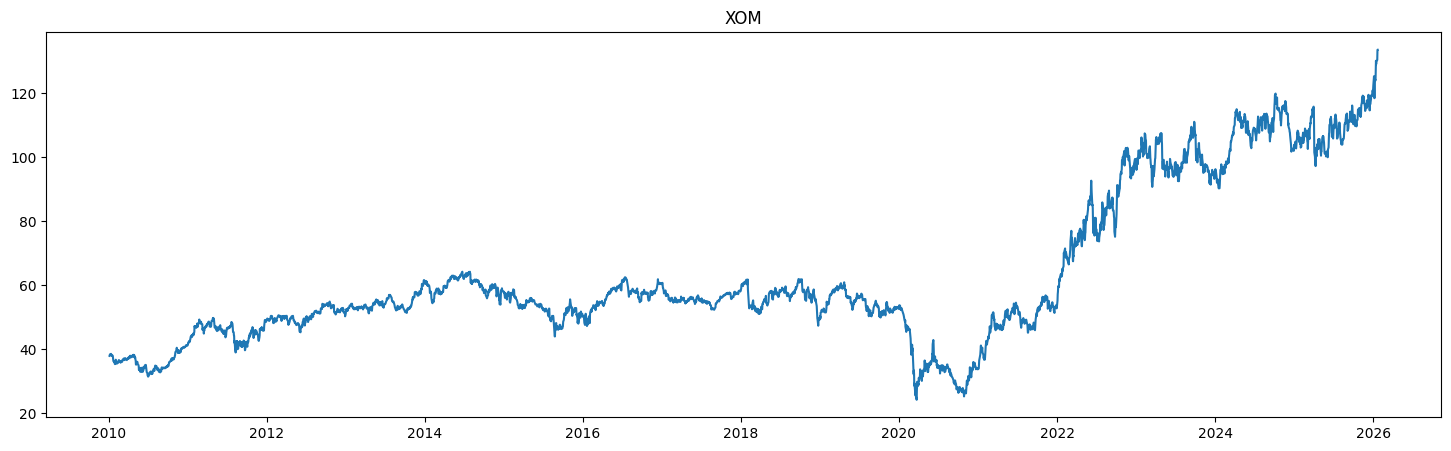

In [17]:
plt.figure(figsize=(18,5))
plt.plot(prices_df[[('Close','XOM')]])
plt.title("XOM")
plt.show()

# correlations of Ford and Exxon returns

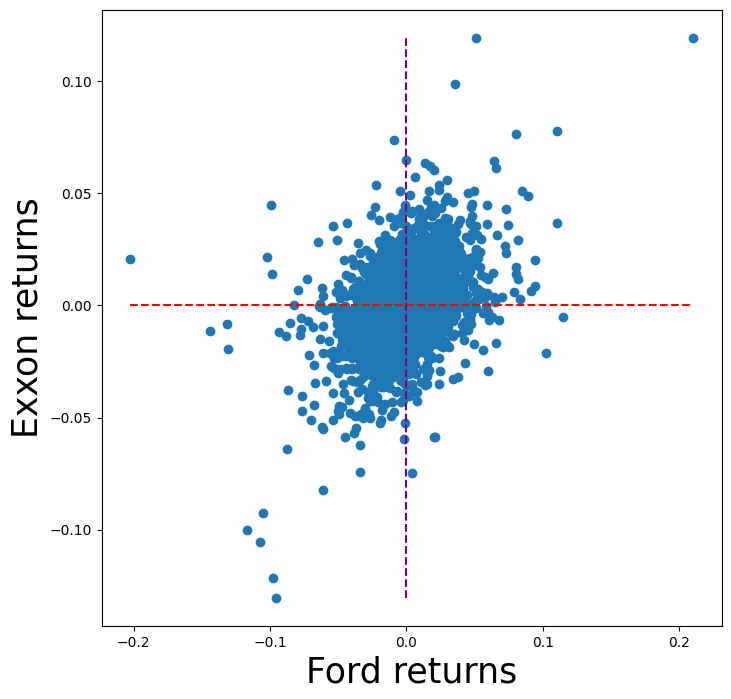

array([[1.        , 0.44153393],
       [0.44153393, 1.        ]])

In [18]:
import numpy as np

plt.figure(figsize=(8,8))
plt.plot(returns_f, returns_xom, 'o')
plt.xlabel('Ford returns', fontsize=25)
plt.ylabel('Exxon returns', fontsize=25)
plt.plot((0,0), (min(returns_xom[1:]), max(returns_xom[1:])),'--',color='purple')
plt.plot((min(returns_f[1:]), max(returns_f[1:])), (0,0),'--',color='red')
plt.show()

np.corrcoef(returns_f[1:], returns_xom[1:])

In [19]:
ticker = "XOM"
stock = yf.Ticker(ticker)
company_info = stock.info

print(f"""ticker: {ticker}
name: {company_info.get('longName','*')}
sector: {company_info.get('sector','*')}
industry: {company_info.get('industry','*')}
""")

company_info

ticker: XOM
name: Exxon Mobil Corporation
sector: Energy
industry: Oil & Gas Integrated



{'address1': '22777 Springwoods Village Parkway',
 'city': 'Spring',
 'state': 'TX',
 'zip': '77389-1425',
 'country': 'United States',
 'phone': '972-940-6000',
 'website': 'https://corporate.exxonmobil.com',
 'industry': 'Oil & Gas Integrated',
 'industryKey': 'oil-gas-integrated',
 'industryDisp': 'Oil & Gas Integrated',
 'sector': 'Energy',
 'sectorKey': 'energy',
 'sectorDisp': 'Energy',
 'longBusinessSummary': 'Exxon Mobil Corporation engages in the exploration and production of crude oil and natural gas in the United States, Guyana, Canada, the United Kingdom, Singapore, France, and internationally. It operates through Upstream, Energy Products, Chemical Products, and Specialty Products segments. The Upstream segment explores for and produces crude oil and natural gas. The Energy Products segment offers fuels, aromatics, and catalysts, as well as licensing services. The Chemical Products segment manufactures and sells petrochemicals, including olefins, polyolefins, and intermedi